# Hypothesis Testing - T-Test

**Assumption:** data → Normal Distribution

1. Population → mean ($\mu$)
2. Sample → Mean ($\bar{x}$), Std ($S$)
3. No. of samples ($n$) < 30

When the sample size is small (n < 30) and/or the population standard deviation is unknown, we use the **t-test** instead of the z-test.

## T-Test Formula

$$t_{test} = \dfrac{\bar{x} - \mu}{\dfrac{S}{\sqrt{n}}}$$

Where:
- $\bar{x}$ = Sample Mean
- $\mu$ = Population Mean
- $S$ = Std of Sample
- $n$ = No. of samples

### Z-Test vs T-Test
| | Z-Test | T-Test |
|---|---|---|
| Sample size | n ≥ 30 | n < 30 |
| Population std | known | unknown (use sample std $S$) |
| Distribution used | Normal (Z) | Student's t-distribution |

In [1]:
import scipy.stats as st
import numpy as np

## Example 1 (One-Tailed T-Test). 

A manufacturer claims that the average weight of a bag of potato chips is **150 grams**. A sample of **25 bags** is taken, and the average weight is found to be **148 grams**, with a standard deviation of **5 grams**. Test the manufacturer's claim using a **one-tailed t-test** with a significance level of **0.05**.

**Given:**
- $\mu = 150$ (claimed population mean)
- $\bar{x} = 148$ (sample mean)
- $n = 25$ (sample size)
- $S = 5$ (sample std)
- $\alpha = 0.05$

**Hypotheses:**
- $H_0: \mu = 150\ gm$ — the claim is true
- $H_a: \mu < 150\ gm$ — actual average weight is less than claimed (left-tailed, since we're only checking for *underfilling*, not any deviation)

### What are we actually finding out, and why?

We want to know: is the gap between the sample mean (148g) and the claimed mean (150g) big enough to be real, or could it just be random sampling noise? The t-test converts that gap into a standardized score ($t_{test}$) and checks it against how much variation we'd expect by chance alone (the t-distribution for this sample size). If our score falls further into the tail than chance would reasonably allow ($\alpha = 0.05$, i.e. only a 5% chance region), we conclude the underfilling is statistically real and reject the manufacturer's claim.

### Step 1 - Degrees of Freedom

$$df = n - 1 = 25 - 1 = 24$$

We need `df` because the t-distribution's exact shape (how fat its tails are) depends on sample size — with fewer samples, we're less certain about the true spread, so the tails are fatter and the critical value is larger than a z-score would be.

### Step 2 - Critical t-value (from t-table)

Look up the t-table at **df = 24**, **one-tail = 0.05** → $t_{critical} = 1.711$.

Since $H_a: \mu < 150$ is left-tailed, the rejection region sits on the *left* side of the distribution, so the critical value used for comparison is $t_{critical} = -1.711$.

The plot below reproduces the sketch: the curve is the t-distribution (df=24), the shaded left tail is the **Ha (reject $H_0$)** rejection region worth $\alpha = 0.05$ of the area, the dashed line at $t=0$ marks **$H_0$**, and the boundary between them is $t = -1.711$.

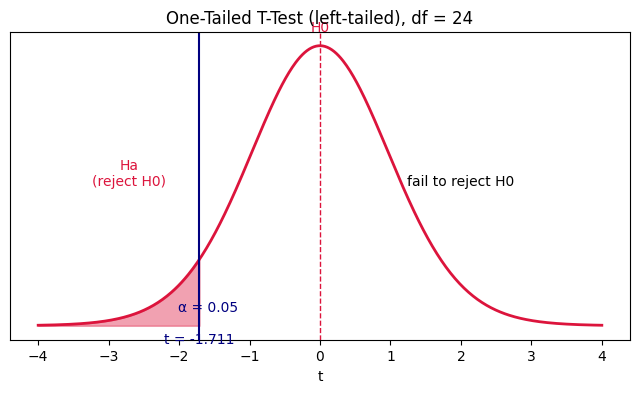

In [2]:
import matplotlib.pyplot as plt

df_ = 24
t_crit = st.t.ppf(0.05, df_)          # -1.7109
x = np.linspace(-4, 4, 500)
y = st.t.pdf(x, df_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="crimson", linewidth=2)

# shade rejection region (Ha) - left tail
x_reject = np.linspace(-4, t_crit, 100)
ax.fill_between(x_reject, st.t.pdf(x_reject, df_), color="crimson", alpha=0.4)

# H0 dashed centerline
ax.axvline(0, color="crimson", linestyle="--", linewidth=1)
ax.text(0, max(y) * 1.05, "H0", ha="center", color="crimson")

# critical t-value line + label
ax.axvline(t_crit, color="navy", linewidth=1.5)
ax.text(t_crit, -0.01, f"t = {t_crit:.3f}", ha="center", va="top", color="navy")

ax.text(t_crit - 1, max(y) * 0.5, "Ha\n(reject H0)", ha="center", color="crimson")
ax.text(2, max(y) * 0.5, "fail to reject H0", ha="center", color="black")
ax.text(t_crit - 0.3, 0.02, "α = 0.05", color="navy")

ax.set_yticks([])
ax.set_xlabel("t")
ax.set_title("One-Tailed T-Test (left-tailed), df = 24")
plt.show()

### Step 3 - Calculate the test statistic

$$t_{test} = \dfrac{\bar{x} - \mu}{\dfrac{S}{\sqrt{n}}} = \dfrac{148 - 150}{\dfrac{5}{\sqrt{25}}} = \dfrac{-2}{1} = -2$$

### Step 4 - Decision rule

Reject $H_0$ if $t_{test}$ is **more extreme** (further into the tail) than $t_{critical}$:

$$t_{test} (-2) < t_{critical} (-1.711)$$

This is true, so $t_{test}$ falls inside the rejection region → **reject $H_0$, accept $H_a$**.

**Conclusion:** At the 5% significance level, there is enough evidence to say the average bag weight is significantly less than the claimed 150 grams — the manufacturer's claim does not hold up.

In [4]:
x_bar = 148
p_u = 150
s_std = 5
n = 25
alpha = 0.05
df = n - 1

t_critical = st.t.ppf(alpha, df)   # left-tailed -> use alpha directly, not 1-alpha
t_test = (x_bar - p_u) / (s_std / np.sqrt(n))

print("df:", df)
print("t_critical:", t_critical)
print("t_test:", t_test)

if t_test < t_critical:
    print("Reject H0 -> Ha is right (avg weight < 150 gm)")
else:
    print("Fail to reject H0 -> H0 is right (avg weight = 150 gm)")

df: 24
t_critical: -1.7108820799094284
t_test: -2.0
Reject H0 -> Ha is right (avg weight < 150 gm)
